In [20]:
#pip install xskillscore

In [21]:
#pip install cmap

In [22]:
#pip install mpl-tools

In [23]:
#pip install global_land_mask

In [24]:
#pip install scikit-image

In [25]:
#conda install geocat-viz

In [26]:
#conda install geocat-comp

In [1]:
import os
import collections
import xarray as xr
import xskillscore as xs
import numpy as np
import pandas as pd
import glob
from datetime import datetime
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from global_land_mask import globe

from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt, sosfilt,lfilter

#from mpl_toolkits.basemap import Basemap

from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon

import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects

import cmaps as gvcmaps
import geocat.viz.util as gvutil
import geocat.viz as gv

In [16]:
def draw_rgmn_ts(fig_path,rgmn_df,region,mip,exp,case,relm,case_id,var,vunt,period):
  time         = rgmn_df['time']
  xtime        = np.linspace(1,len(time),len(time))
  tsa_series   = np.array(rgmn_df['rgmn_idx'])  #.reshape(len(time))
  rtsa_series  = np.array(rgmn_df['rrgmn_idx']) #.reshape(len(time))
  rgmn_series  = np.array(rgmn_df['rgmnSD_idx'])   #.reshape(len(time))
  rrgmn_series = np.array(rgmn_df['rrgmnSD_idx'])  #.reshape(len(time))
  years        = int(time[0].split("-")[0])
  yeare        = int(time[len(time)-1].split("-")[0])

  # -- figure plot
  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

  xtick = np.arange(0,len(time))
  xlabs = np.arange(0,len(time)) / 12.0  + years
  fontsize = 16
  # Create a list of colors based on the color bar values
  #colors = ['C1' if (value > 0) else 'C0' for value in rgmnSD]

  # Plot bar chart
  #ax1.bar(xtime, rgmn, align='edge', edgecolor="none", color=colors, width=1.0)
  #ax1.plot(xtime, rrgmn, color="black", linewidth=1.5)
  #ax1.legend(['7-month running mean'])

  #ax2.bar(xtime, rgmnSD, align='edge', edgecolor="none", color=colors, width=1.)
  #ax2.plot(xtime, rrgmnSD, color="black", linewidth=1.5)
  vmin1 = min([min(rtsa_series),min(tsa_series)])
  vmax1 = max([max(rtsa_series),max(tsa_series)])
  ax1.plot(xtime, rtsa_series, 'black', alpha=1.00, linewidth=2)
  ax1.fill_between(xtime, 0., tsa_series, tsa_series> 0., color='red',   alpha=.75)
  ax1.fill_between(xtime, 0., tsa_series, tsa_series< 0., color='blue',  alpha=.75)
  #ax1.xaxis.tick_top()
  ax1.set_title("Raw rgmn index {}({})".format(var,vunt), fontsize=fontsize*1.1)
  ax1.set_xlabel("years", fontsize=fontsize*1.1)
  ax1.set_ylabel("{}({})".format(var,vunt), fontsize=fontsize*1.1)
  ax1.legend(['5-month running mean'])
  ax1.set_ylim(vmin1, vmax1)
  ax1.set_xlim(0,len(time))
  ax1.set_xticks(xtick[::120])
  ax1.set_xticklabels(xlabs[::120].astype(int))
  ax1.tick_params(labelsize=fontsize)
  ax1.grid(True)

  vmin2 = min([min(rrgmn_series),min(rgmn_series)])
  vmax2 = max([max(rrgmn_series),max(rgmn_series)])
  ax2.plot(xtime, rrgmn_series, 'black', alpha=1.00, linewidth=2)
  ax2.fill_between(xtime, 0., rgmn_series, rgmn_series> 0., color='red',   alpha=.75)
  ax2.fill_between(xtime, 0., rgmn_series, rgmn_series< 0., color='blue',  alpha=.75)
  #ax2.xaxis.tick_top()
  ax2.set_title("Standardized rgmn index {}({})".format(var,vunt), fontsize=fontsize*1.1)
  ax2.set_xlabel("years", fontsize=fontsize*1.1)
  ax2.set_ylabel("{}({})".format(var,'unitless'), fontsize=fontsize*1.1)
  ax2.legend(['5-month running mean'])
  ax2.set_ylim(vmin2, vmax2)
  ax2.set_xlim(0,len(time))
  ax2.set_xticks(xtick[::120])
  ax2.set_xticklabels(xlabs[::120].astype(int))
  ax2.tick_params(labelsize=fontsize)
  ax2.grid(True)
  #plt.draw()
  plt.tight_layout()
  plt.show()
    
  if not os.path.exists(fig_path):
    os.makedirs(fig_path)
  fig_name = "fig_ts_{}_{}_{}_{}_{}_{}_{}.pdf".format(mip,exp,case,relm,case_id,var,period)
  plt.savefig(os.path.join(fig_path, fig_name))
  plt.close()

  return

In [3]:
# -- Detrending
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit

In [4]:
def draw_rgmn_map(out_path,fig_path,da,rgmn_df,region,mip,exp,case,relm,case_id,period):
  lons  = da['longitude'][:]
  lats  = da['latitude'][:]
  clm   = da.groupby('time.month').mean(dim='time')
  anm   = (da.groupby('time.month') - clm)
  var   = da.name
  vstr  = da.name.upper()
  vunt  = da.units
  #nt,nlat,nlon = anm.shape
  #ngrd         = nlat*nlon
  #nyr          = nt/12
  #print(nt,nlat,nlon,ngrd,nyr)

  #tsa_series  = rgmn_df['rgmn_idx']  #.reshape(len(time))
  #rtsa_series = rgmn_df['rrgmn_idx'] #.reshape(len(time))
  #rgmn_series  = rgmn_df['rgmnSD_idx']   #.reshape(len(time))
  #rrgmn_series = rgmn_df['rrgmnSD_idx']  #.reshape(len(time))
  time    = rgmn_df['time']
  xtime   = np.linspace(1,len(time),len(time))
  rgmn_df = rgmn_df.set_index('time')
  rgmn    = rgmn_df['rgmn_idx'].to_xarray()
  rgmn    = rgmn.assign_coords({"time": da.time})
  rgmnSD  = rgmn/rgmn.std(dim='time')

  years   = int(time[0].split("-")[0])
  yeare   = int(time[len(time)-1].split("-")[0])
  # -- filtering (or Running mean)
  #rrgmnSD    = rgmnSD.rolling(time=5, center=True).mean('time')
  #ranm       = anm.rolling(time=5, center=True).mean('time')
  rrgmnSD     = rgmnSD
  ranm        = anm
  rrgmnSD[:]  = low_pass(1.0/5.0,rgmnSD,axis=0) #5-month: 1/5.0
  if np.isnan(anm).any():
    tmp1 = ranm.fillna(-99999)
    tmp1 = low_pass(1.0/5.0,tmp1,axis=0)
    ranm = anm
    ranm[:,:,:] = tmp1[:,:,:]
    ranm = ranm.where(ranm > -10000)
    del(tmp1)
  else:
    ranm[:,:,:] = low_pass(1.0/5.0,anm[:,:,:],axis=0)
  rdanm = detrend_dim(ranm,'time',1)
  #print(np.nanmax(ranm),np.nanmin(ranm))
  #print(np.nanmax(rdanm),np.nanmin(rdanm))

  # simultaneous
  #vreg,pval = pearsonr(rrgmnSD,rdanm,axis=0)
  vcor = xr.corr(rrgmnSD, rdanm, dim="time")
  vreg = xr.cov(rrgmnSD, rdanm, dim="time")/rrgmnSD.var(dim='time',skipna=True).values
  pval = xs.pearson_r_p_value(rrgmnSD, rdanm, dim="time",skipna=True)

  #correlation at 5% significant level
  vsig = vreg.copy()
  #vsig = np.ma.masked_array(vreg, mask=(pval>=0.05)) #np.where(pval >= 0.05,np.nan,vreg)
  vsig = vsig.where(pval<=0.05)

  save_figure_data(vcor,vreg,pval,vsig,mip,exp,case,relm,case_id,vstr,vunt,period,out_path)

  # Show the plot
  vmin  = vreg.min().values
  vmax  = vreg.max().values
  vmax  = max([abs(vmin),abs(vmax)])
  vmin  = vmax * -1.0
  nlev  =  21
  fontsize = 16
  bartitle = 'Regressed {}({})'.format(vstr,vunt)
  fig = plt.figure(figsize=(10, 12))
  grid = fig.add_gridspec(ncols=1, nrows=1)
  ax1, fill1 = draw_regression_map(vstr,vunt,lons,lats,vcor,vreg,pval,fig,region,
                                   fontsize,'{}-{} Pattern'.format(case_id.upper(),vstr.upper()),grid[0,0],vmin,vmax,nlev)
  cb = fig.colorbar(fill1,
                    ax=[ax1],
                    drawedges=True,
                    orientation='horizontal',
                    shrink=0.95,
                    aspect=40,
                    pad=0.05,
                    extendfrac='auto',
                    extendrect=True)
  ticks  = np.linspace(vmin, vmax, nlev)
  labels = []
  for i,tick in enumerate(ticks):
    if i % 2 == 0:
      labels.append('{:0.1f}'.format(tick))
    else:
      labels.append('')
  cb.set_ticks(ticks=ticks,labels=labels,fontsize=fontsize*0.9)
  cb.set_label(label=bartitle,fontsize=fontsize*0.95)

  plt.rcParams["font.family"] = "sans-serif"
  plt.rcParams.update({'font.size': fontsize})
  plt.draw()

  plt.show()
  if not os.path.exists(fig_path):
    os.makedirs(fig_path)
  fig_name = "fig_2d_map_{}_{}_{}_{}_{}_{}_{}.pdf".format(mip,exp,case,relm,case_id,var,period)
  plt.savefig(os.path.join(fig_path, fig_name))
  plt.close()

  return

In [5]:
def draw_regression_map(vstr,vunt,lats,lons,cor,reg,pval,fig,region,fontsize,title,grid_space,vmin,vmax,nlev):
  sig    = pval
  sig[:] = 1.0 - sig[:]
  t90    = 0.94
  t95    = 0.95
  rlabel = '{}({})'.format(vstr,vunt)

  # Generate axes using Cartopy to draw coastlines
  ax = fig.add_subplot(grid_space,
          projection=ccrs.PlateCarree(central_longitude=210))
  ax.coastlines(linewidth=0.5, alpha=0.6)

  # Use geocat.viz.util convenience function to set axes limits & tick values
  gvutil.set_axes_limits_and_ticks(ax,
                                 xlim=(-180, 180),
                                 ylim=(-90, 90),
                                 xticks=np.arange(-180, 181, 60),
                                 yticks=np.arange(-90, 91, 30))

  # Use geocat.viz.util convenience function to add minor and major tick lines
  gvutil.add_major_minor_ticks(ax, labelsize=fontsize*0.90)

  # Use geocat.viz.util convenience function to make latitude, longitude tick labels
  gvutil.add_lat_lon_ticklabels(ax)
  # Import the default color map
  newcmp = gvcmaps.BlueYellowRed
  index = [5, 20,  35, 50, 65, 85, 95, 110, 125,  0, 0, 135, 150,  165, 180, 200, 210, 220, 235, 250 ]
  color_list = [newcmp[i].colors for i in index]
  #-- Change to white
  color_list[9]=[ 1., 1., 1.]
  color_list[10]=[ 1., 1., 1.]

  # Define dictionary for kwargs
  kwargs = dict(
    vmin = vmin,
    vmax = vmax,
    levels = nlev,
    colors=color_list,
    add_colorbar=False,  # allow for colorbar specification later
    transform=ccrs.PlateCarree(),  # ds projection
  )

  # Contouf-plot U data (for filled contours)
  fillplot = cor.plot.contourf(ax=ax,  **kwargs)

  # Draw map features on top of filled contour
  #ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
  #ax.add_feature(cfeature.COASTLINE, edgecolor='gray', linewidth=0.5, zorder=1)
  ax.add_feature(cfeature.LAND, facecolor='none', zorder=1)
  ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5, zorder=1)

  # Plot Hatch for significance
  sig.plot.contourf(ax=ax, levels = [-1*t95, -1*t90, t90, t95], colors='none',
      hatches=[None, None, None, '..', '..'], extend='both',
      add_colorbar=False, transform=ccrs.PlateCarree())

  # Plot line contours
  # Specify contour levels excluding 0
  delc=0.2
  levels = np.arange(-3, 0, delc)
  levels = np.append(levels, np.arange(delc, 3, delc))

  rad = reg.plot.contour(ax=ax,
                  colors='black',
                  alpha=0.8,
                  linewidths=1.0,
                  add_labels=False,
                  levels=levels,
                  transform=ccrs.PlateCarree())
#  ax.clabel(rad, levels, fmt='%1.1f',  inline=True, colors='black', fontsize=fontsize)
  pe = [PathEffects.withStroke(linewidth=2.0, foreground="w")]
  plt.setp(rad.collections, path_effects=pe)

  # Use geocat.viz.util convenience function to add titles to left and right of the plot axis.
  gvutil.set_titles_and_labels(ax,
                             lefttitle=title,
                             lefttitlefontsize=fontsize*0.95,
                             righttitle=rlabel,
                             righttitlefontsize=fontsize*0.95,
                             labelfontsize = fontsize*0.95,
                             xlabel="",
                             ylabel="")

  # add mark for specific location 
  #df2 = rgmn_df[ rgmn_df['time'] == str(da_2D.time.values)[0:10]]
  #if len(df2) > 0:
  #  ax.plot(df2['lon'], df2['lat'], 'mx', transform=ccrs.PlateCarree() )

  #add a box for region 
  #draw_regional_box(region)
  #draw_screen_poly(region,m)

  #turn off ticks on top and right
  ax.xaxis.tick_bottom()
  ax.yaxis.tick_left()

  return ax, fillplot

In [6]:
def save_figure_data(vcor,vreg,pval,vsig,mip,exp,case,relm,case_id,var,vunt,period,out_path):
  #create xarray to save data
  lons,lats = vcor.longitude,vcor.latitude
  df = xr.Dataset(
          {   "varreg": (["lat", "lon"], vreg.data),
              "varsig": (["lat", "lon"], vsig.data),
              "varcor": (["lat", "lon"], vcor.data),
              "pval": (["lat", "lon"], pval.data),
              },
          coords={
              "lon": (["lon"], lons.data),
              "lat": (["lat"], lats.data),
              },
          attrs=dict(description="rgmn regression maps",
                    reference_time=period),
          )


  df.lat.attrs["units"] = "degree_north"
  df.lon.attrs["units"] = "degree_east"
  df.varcor.attrs["units"] = "1"
  df.varcor.attrs["long_name"] = "Correlation Coefficient"
  df.varreg.attrs["units"] = vunt
  df.varreg.attrs["long_name"] = "Regression Maps"
  df.varsig.attrs["units"] = vunt
  df.varsig.attrs["long_name"] = "Regression Maps (significant at 0.05 confidence level)"
  df.pval.attrs["units"] = "1"
  df.pval.attrs["long_name"] = "p values"

  #save data to netcdf
  if not os.path.exists(out_path):
    os.makedirs(out_path)
  fout_name = "{}_{}_{}_{}_{}_{}_{}.nc".format(mip,exp,case,relm,case_id,var,period)
  df.to_netcdf(os.path.join(out_path,fout_name))
    
  return

In [7]:
def draw_screen_poly(region, m):
  '''
  Draw box around a region on a map
  region is a dictionary with west,east,south,north
  '''
  lat0 = region['north']
  lat1 = region['south']
  lon0 = region['east']
  lon1 = region['west']
  if lon1 < 0.0:
     lon1 + 360.0
  if lon0 < 0.0:
     lon0 + 360.0

  lats = [ lat1, lat0, lat0, lat1 ]
  lons = [ lon1, lon1, lon0, lon0 ]

  x, y = m(lons,lats)
  xy   = zip(x,y)

  poly = Polygon( xy, facecolor='red', alpha=0.4 )
  plt.gca().add_patch(poly)

  return


In [8]:
def draw_regional_box( region, transform=None ):
  '''
  Draw box around a region on a map
  region is a dictionary with west,east,south,north
  '''
  if transform == None:
      transform = ccrs.PlateCarree()

  plt.plot([region['west'], region['west']], [region['south'],region['north']],
               'k-', transform=transform, linewidth=1)
  plt.plot([region['east'], region['east']], [region['south'],region['north']],
               'k-', transform=transform, linewidth=1)

  for i in range( np.int32(region['west']),np.int32(region['east']) ):
      plt.plot([i,i+1], [region['south'],region['south']], 'k-', transform=transform, linewidth=1)
      plt.plot([i,i+1], [region['north'],region['north']], 'k-', transform=transform, linewidth=1)

  return 


In [9]:
def plot_regions_mask(fig_path, da, da_mask, group):
  if not os.path.exists(fig_path):
      os.makedirs(fig_path)
  plt.figure(figsize=(12,6))
  ax1 = plt.subplot(211, projection=ccrs.PlateCarree(central_longitude=0.,globe=None) )
  ax1.set_extent([-180,110,-10,10], ccrs.PlateCarree())
  da.isel(time=-1).plot.pcolormesh('longitude', 'latitude', cmap='jet',
                                   transform=ccrs.PlateCarree(), add_colorbar=False )
  ax2 = plt.subplot(212, projection=ccrs.PlateCarree(central_longitude=0.,globe=None) )
  ax2.set_extent([-180,110,-10,10], ccrs.PlateCarree())
  da_mask.isel(time=-1).plot.pcolormesh('longitude', 'latitude', cmap='jet',
                                        transform=ccrs.PlateCarree(), add_colorbar=False )
  plt.show()
  plt.savefig(os.path.join(fig_path, "region_{}.pdf".format(case)))
  plt.close()
  return


In [10]:
def low_pass(cutoff_freq, data, order=5, axis=-1):
    #low-pass: filtering high-frequency signal
    #nyquist normalized cutoff for digital design
    Wn = cutoff_freq
    b, a = butter(order, Wn, btype='lowpass', analog=False)
    data_filt = filtfilt(b, a, data, axis=axis, method="gust")
    return data_filt

In [11]:
def define_rgmn(da,region):
  '''
  da for one point in time (with lats x lons)
  '''
  #years = list(da.time.dt.year.data)
  times = da.time.dt.strftime("%Y-%m-%d")
  time_str = da.time.dt.strftime("%Y-%m-%d")
  ntime = len(times)

  print("number of total months in data: ", ntime)

  lons, lats = da.longitude, da.latitude
  #Adju[I 13:45:33.438 NotebookApp] Saving file at /paper_material/6_regional_analysis/ozone_mean_ts/gen_rgmn_index.ipynb
  latN = region['north']
  latS = region['south']
  lonE = region['east']
  lonW = region['west']
  if ( ((lonW < 0) or (lonE < 0 )) and (lons.values.min() > -1) ):
     da = da.assign_coords(longitude=((lons + 180) % 360 - 180) )
     lons = ( (lons + 180) % 360 - 180)
  #lon_name = "longitude"
  #ds['_longitude_adjusted'] = xr.where(ds[lon_name] > 180,ds[lon_name] - 360,ds[lon_name])
  #ds = (ds.swap_dims({lon_name: '_longitude_adjusted'})
  #        .sel(**{'_longitude_adjusted': sorted(ds._longitude_adjusted)})
  #        .drop(lon_name))
  #ds = ds.rename({'_longitude_adjusted': lon_name})
  clm  = da.groupby('time.month').mean(dim='time')
  anm  = (da.groupby('time.month') - clm)
  dclm = anm.copy()
  for i in range(len(clm)):
    dclm[i::12,:,:] = clm[i,:,:].copy()

  iplat = lats.where( (lats >= latS ) & (lats <= latN), drop=True)
  iplon = lons.where( (lons >= lonW ) & (lons <= lonE), drop=True)

  wgt = np.cos(np.deg2rad(lats))
  rgmn_sst = da.sel(latitude=iplat,longitude=iplon).weighted(wgt).mean(("longitude", "latitude"), skipna=True)
  rgmn_clm = dclm.sel(latitude=iplat,longitude=iplon).weighted(wgt).mean(("longitude", "latitude"), skipna=True)

  # -- Calculate rgmn3.4 index
  rgmn_ind    = anm.sel(latitude=iplat,longitude=iplon).weighted(wgt).mean(("longitude", "latitude"), skipna=True)
  rgmnSD_ind  = rgmn_ind / rgmn_ind.std(dim='time')
  #instead of moving average, using a low-pass filtering 
  #rrgmn_ind   = rgmn_ind.rolling(time=5, center=True).mean('time')
  #orgmn_ind   = rgmn_ind.rolling(time=3, center=True).mean('time')
  #rrgmnSD_ind = rgmnSD_ind.rolling(time=5, center=True).mean('time')
  #orgmnSD_ind = rgmnSD_ind.rolling(time=3, center=True).mean('time')
  rrgmn_ind    = low_pass(1.0/5.0,rgmn_ind)   #5-month: 1/5.0
  orgmn_ind    = low_pass(1.0/3.0,rgmn_ind)   #3-month: 1/3.0
  rrgmnSD_ind  = low_pass(1.0/5.0,rgmnSD_ind) #5-month: 1/5.0
  orgmnSD_ind  = low_pass(1.0/3.0,rgmnSD_ind) #3-month: 1/3.0

  df = pd.DataFrame()
  df['rgmn_val']    = rgmn_sst
  df['rgmn_clm']    = rgmn_clm
  df['rgmn_idx']    = rgmn_ind
  df['rgmnSD_idx']  = rgmnSD_ind
  df['rrgmn_idx']   = rrgmn_ind
  df['rrgmnSD_idx'] = rrgmnSD_ind
  df['orgmn_idx']   = orgmn_ind
  df['orgmnSD_idx'] = orgmnSD_ind
  df['time']        = time_str

  ### re-order columns
  df = df[['time','rgmn_val','rgmn_clm','rgmn_idx','rrgmn_idx','orgmn_idx','rgmnSD_idx','rrgmnSD_idx','orgmnSD_idx']]
  ### clean-up DataFrame
  df = df.reset_index(drop=True)
  del(lats,lons,clm,anm,dclm,iplat,iplon,wgt,rgmn_sst,rgmn_clm,rgmn_ind,rrgmn_ind,rgmnSD_ind,rrgmnSD_ind,times,time_str)
  return df

In [12]:
def slice_region(da, region, boarder=1):
  latn = region['north'] + boarder
  lats = region['south'] - boarder
  lone = region['east']  + boarder
  lonw = region['west']  - boarder
  #print("select region for ASL: latn,lats,lone,lonw=",latn,lats,lonw,lone)
  da = da.sel(latitude=slice(lats,latn),longitude=slice(lonw,lone))
  return da

In [13]:
class Case:
  def __init__(self, path, var, color, label):
      self._path  = path
      self._color = color
      self._label = label
      self._var   = var
      self._vstr  = var
      self._vunt  = var
      return

  @property
  def path(self):
      return self._path
  @property
  def color(self):
      return self._color

  @property
  def label(self):
      return self._label

  @property
  def label(var):
      return self._var

  @property
  def label(varunt):
      return self._varunt

  @property
  def label(varstr):
      return self._varstr


In [14]:
if __name__ == "__main__":
  top_path = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project"
  out_path = os.path.join(top_path,"E3SMv21_testings","paper_material","fig_data","ozone_mean_ts","raw_index")
  fig_path = os.path.join(top_path,"E3SMv21_testings","paper_material","6_regional_analysis","ozone_mean_ts","figure")
  # region of interest (rgmn sector)
  regions  = {'antarctic':   {'west':-180., 'east':180.,  'south':-90.,  'north':-65.},
              'so':     {'west':-180., 'east':180.,       'south':-70., 'north':-50.},
              'sh':     {'west':-180., 'east':180.,       'south':-90., 'north':-20.},
              'shex':   {'west':-180., 'east':180.,       'south':-90., 'north':-60.}
              }
  #sanity check (plot region with and without mask) 
  l_check_region = False #True  

  mip       = 'analysis'
  exp       = 'historical'
  relm      = 'en00'
  case_id   = 'rgmn'
  tableId   = "Amon"
  products  = ["NOAA_20C","ERA5"]
  period    = "195001-201412"
  varlist   = ['tco','sco']
  varstrs   = ['TCO','SCO']
  period    = "195001-201412"
  run_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/monthly"
  run_mask  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/fixed/sftlf"
  for i,var in enumerate(varlist):
    for j,product in enumerate(products):
      case = product
      ptmp = os.path.join(run_path,mip,case,tableId,var)
      ftmp = '{}.{}.{}.{}.*.{}.{}.nc'.format(mip,exp,product,relm,var,"*")
      filePath = sorted(glob.glob(os.path.join(ptmp,ftmp)))
      if len(filePath) > 0 and os.path.isfile(filePath[0]):
        data_fil = filePath[0]
        print(data_fil)
        mask_fil = os.path.join(run_mask,tableId,mip+"."+exp+"."+case+".fx.sftlf.nc")
        case_dict = collections.OrderedDict()
        case_dict[case] = Case(data_fil, var=varstrs[i], color="blue", label=case)
        case_dict['mask'] = Case(mask_fil, var="sftlf", color="blue", label=case)
        #call fuction to generate rgmn index 
        for rkey in regions.keys():
          region = regions[rkey]
          run_id = '{}_{}'.format(case_id,rkey)
          main(fig_path,out_path,mip,exp,relm,period,run_id,case_dict,region,l_check_region)
        del(case_dict,case,data_fil,mask_fil)
        
  for key in case_dict:
    if key == "mask":
      dmsk = case_dict[key].path
      vmsk = case_dict[key]._var
    else:
      case = key
      var  = case_dict[key]._var
      data = case_dict[key].path

  print("working on ",case,var)

  #load model data
  ds   = xr.open_dataset(data)
  #select target period
  ymds = '{}-{}-01'.format(period.split("-")[0][0:4],period.split("-")[0][4:6])
  ymde = '{}-{}-31'.format(period.split("-")[1][0:4],period.split("-")[1][4:6])
  ds   = ds.sel(time=slice(ymds,ymde))
  if len(ds.dims) < 3:
    print("data dimension is incorrect")
    exit()
  else:
    if ds[var].dims[1] == "lat" or ds[var].dims[2] == "lon":
      ds = ds.rename({ds[var].dims[1] : 'latitude',
                      ds[var].dims[2] : 'longitude'})

  #load land/sea mask file
  if os.path.exists(dmsk):
    dsm  = xr.open_dataset(dmsk)
    if dsm[vmsk].dims[0] == "lat" or dsm[vmsk].dims[1] == "lon":
      dsm = dsm.rename({dsm[vmsk].dims[0] : 'latitude',
                        dsm[vmsk].dims[1] : 'longitude'})
    mask = dsm[vmsk]
    mask = mask /100.0 #range[0,1]
    #print(mask.min(),mask.max())
  else:
    print("Warning: land/sea mask not exist, derive it...")
    #mask = cdutil.generateLandSeaMask(clt)
    lons, lats = ds.longitude, ds.latitude
    if lons.values.min() > -1:
      lons = ( (lons + 180) % 360 - 180)
    # Make a grid
    lon_grid, lat_grid = np.meshgrid(lons.values,lats.values)
    #global land mask
    mask = globe.is_land(lat_grid, lon_grid)
    del(lons,lats,lon_grid,lat_grid)


  #extract data 
  da = ds[var]
  if var == "TCO" or var == "SCO":
    if da.units != "DU":
      print("warning: inconsistent unit {} ".format(da.units))
    da = da.assign_attrs(units='DU')
    
  ################################
  #sanity check on region
  ################################
  if l_check_region:
    #only select first year to check  
    da_t = ds[var].sel(time=ds[var].time[0:11]) #.dt.year.values[0])
    #Select region and apply land-sea mask
    da_mask = da_t.where(mask == 0)
    ### slice area around ASL region
    da_nmsk = slice_region(da_t, region)
    da_mask = slice_region(da_mask, region)
    print(da_mask)
    print("before mask,min/max: ", da.min(),da.max())
    print("after mask,min/max: ",da_mask.min(),da_mask.max())
    plot_regions_mask(fig_path,da_nmsk,da_mask,case)
    del(da_t,da_mask,da_nmsk)
  ################################
  #end sanity check on region
  ################################

  vstr = da.name.upper()
  vunt = da.units
  #calculate and save rgmn index 
  rgmn_df = define_rgmn(da,region)
  #save data to text file
  if not os.path.exists(out_path):
    os.makedirs(out_path)
  out_file = '{}.{}.{}.{}.{}.{}.{}.csv'.format(mip,exp,case,relm,case_id,vstr,period)
  rgmn_df.to_csv(os.path.join(out_path,out_file),index=False)

  #plot rgmn time series 
  draw_rgmn_ts(fig_path,rgmn_df,region,mip,exp,case,relm,case_id,vstr,vunt,period)

  #plot map with rgmn regression on TS
  draw_rgmn_map(out_path,fig_path,ds[var],rgmn_df,region,mip,exp,case,relm,case_id,period)
    

/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/monthly/analysis/NOAA_20C/Amon/tco/analysis.historical.NOAA_20C.en00.mon.tco.185301-201512.nc
working on  NOAA_20C TCO


/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'TCO' has multiple fill values {np.float32(-9999.0), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


number of total months in data:  780


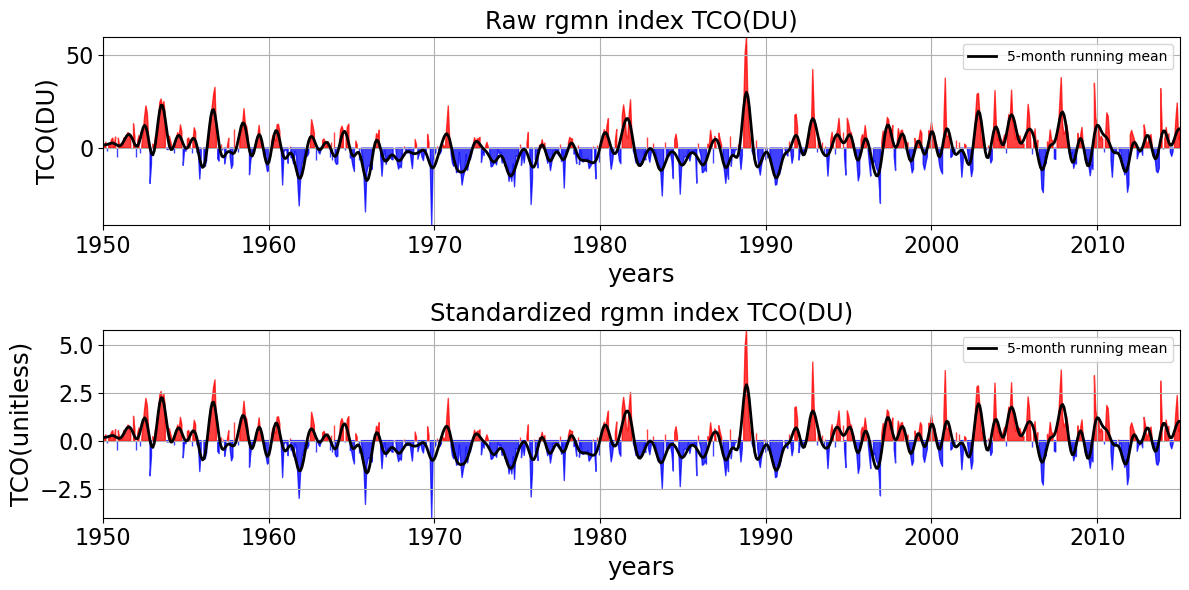

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


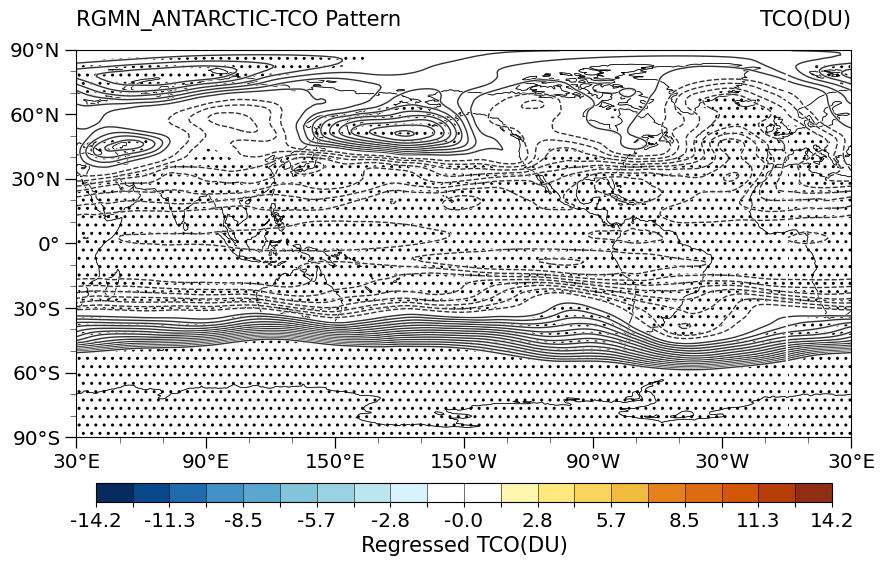

working on  NOAA_20C TCO
number of total months in data:  780


/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'TCO' has multiple fill values {np.float32(-9999.0), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


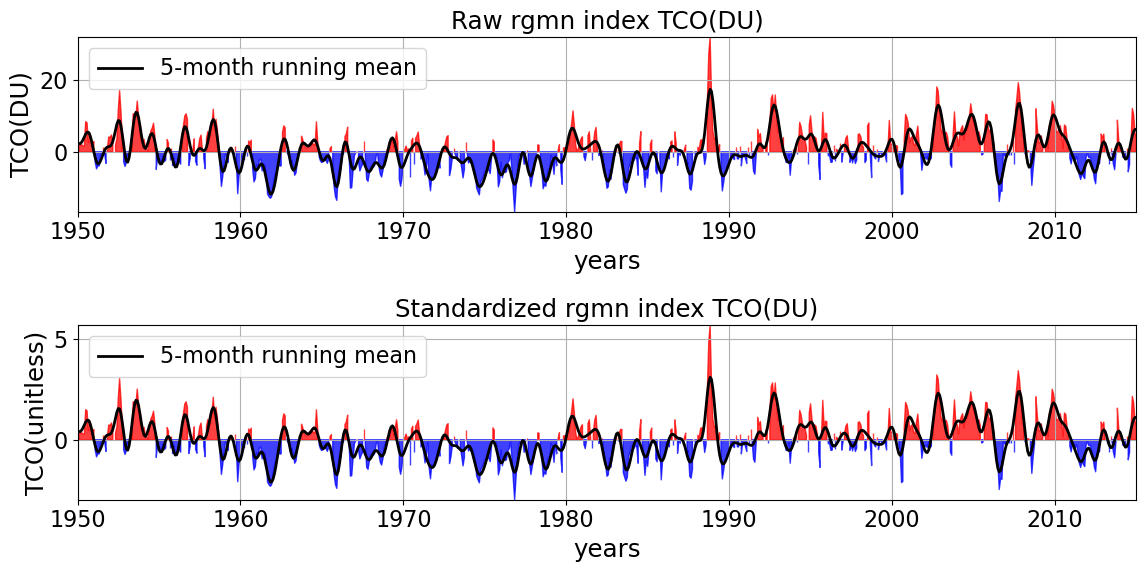

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


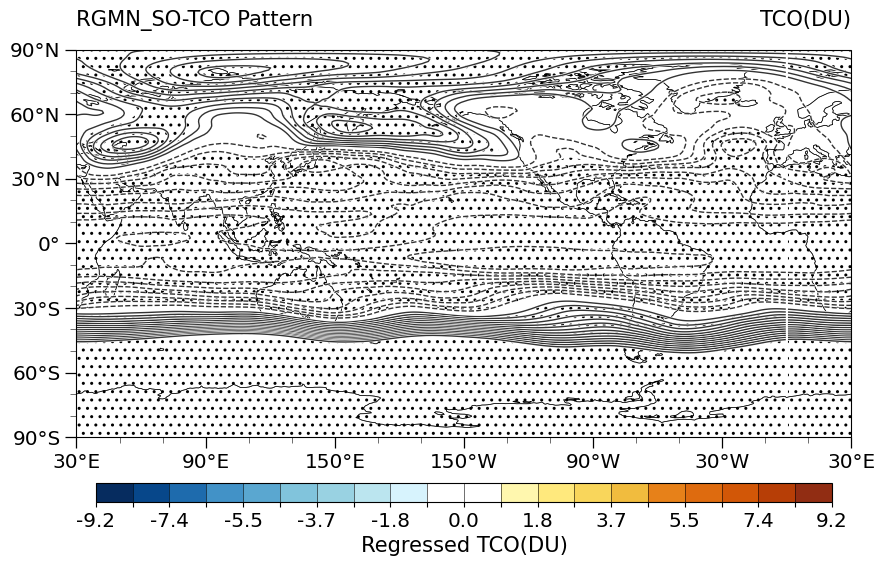

working on  NOAA_20C TCO
number of total months in data:  780


/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'TCO' has multiple fill values {np.float32(-9999.0), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


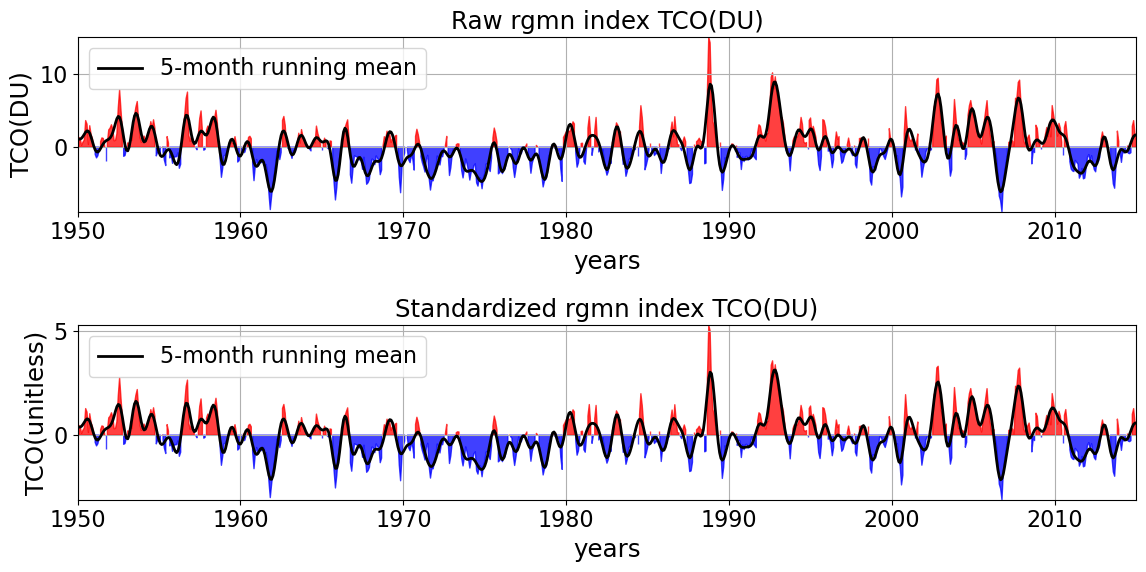

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


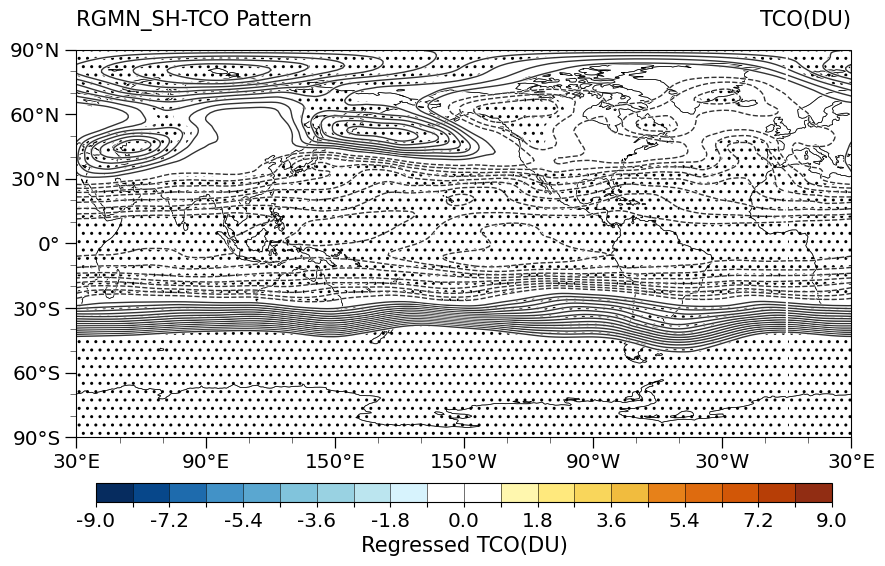

working on  NOAA_20C TCO
number of total months in data:  780


/home/ac.szhang/.conda/envs/pcmdi_metrics_master/lib/python3.9/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'TCO' has multiple fill values {np.float32(-9999.0), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


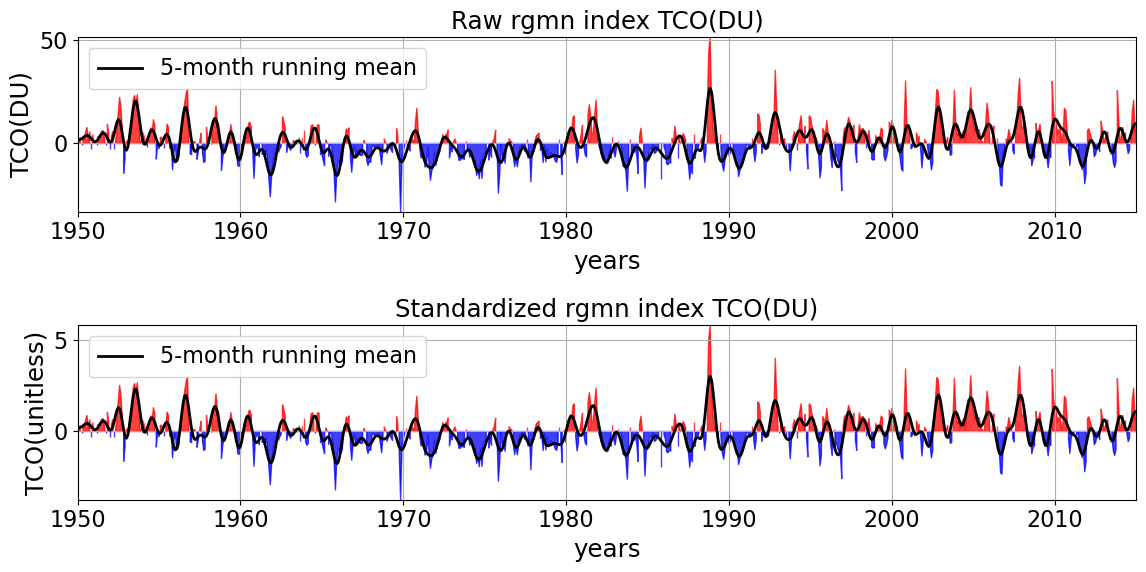

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


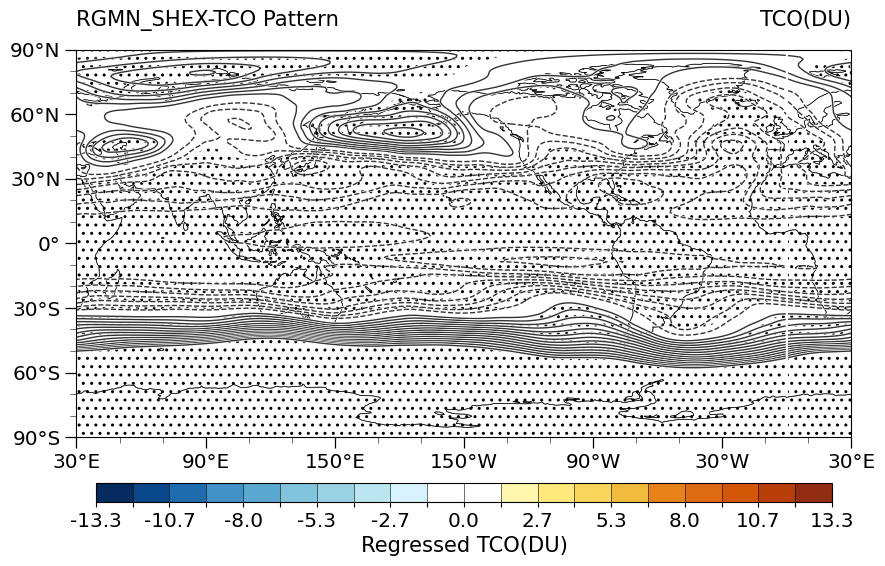

/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/monthly/analysis/ERA5/Amon/tco/analysis.historical.ERA5.en00.mon.tco.197901-201812.nc
working on  ERA5 TCO
number of total months in data:  432


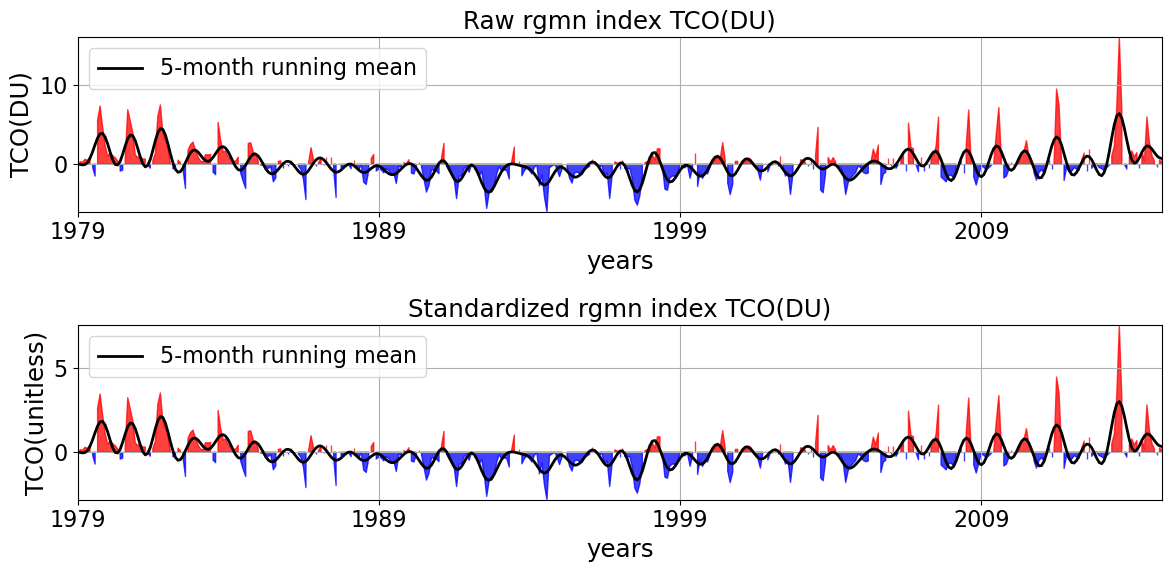

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


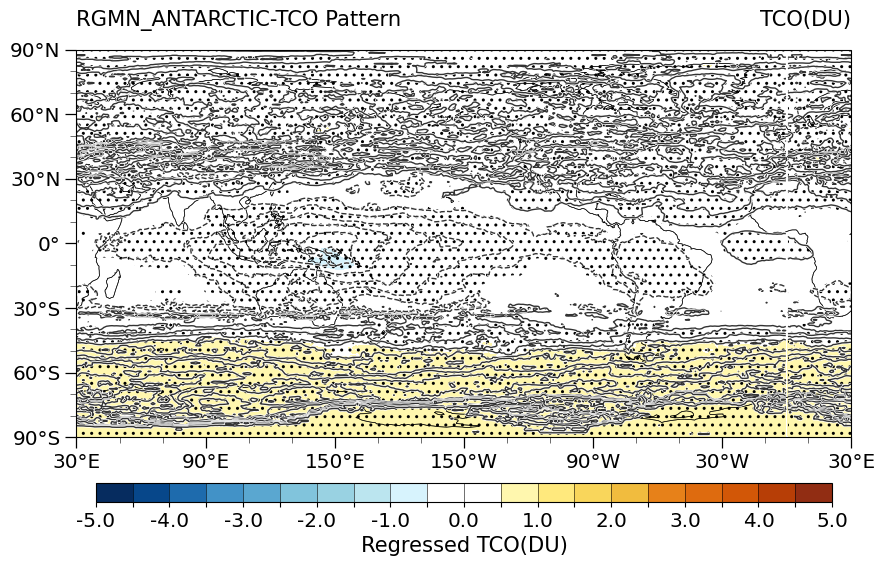

working on  ERA5 TCO
number of total months in data:  432


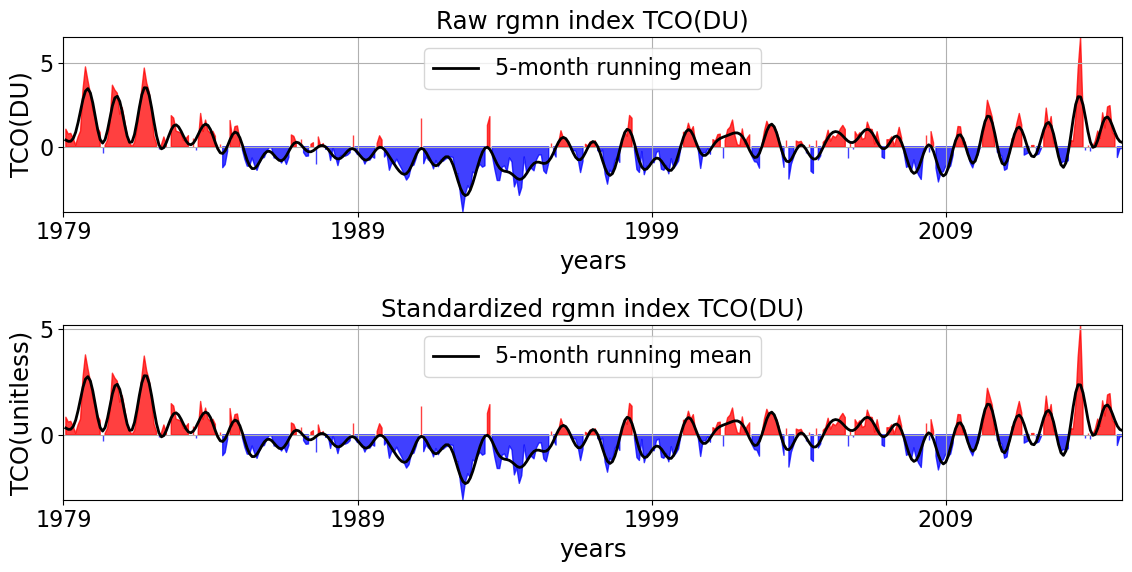

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


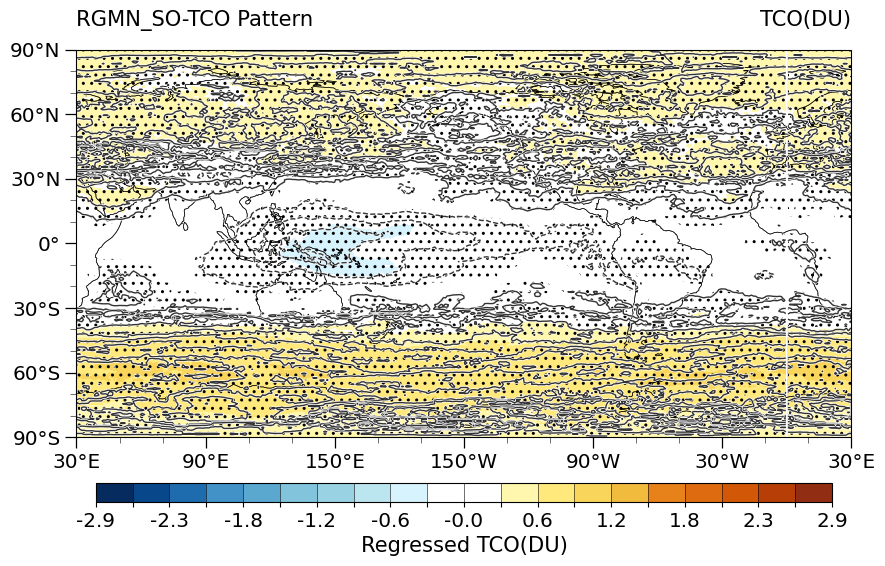

working on  ERA5 TCO
number of total months in data:  432


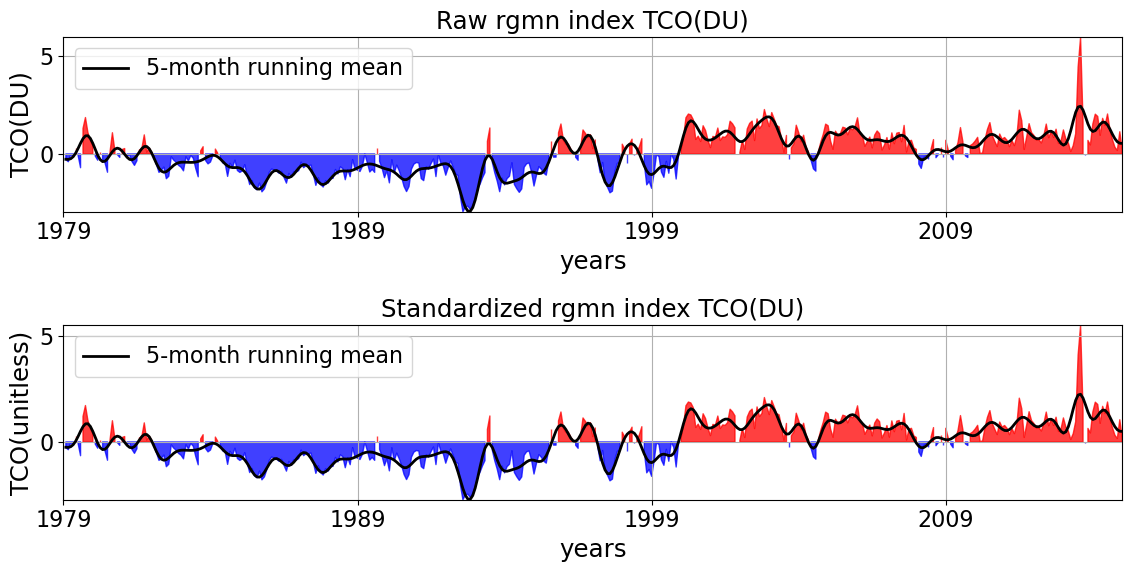

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


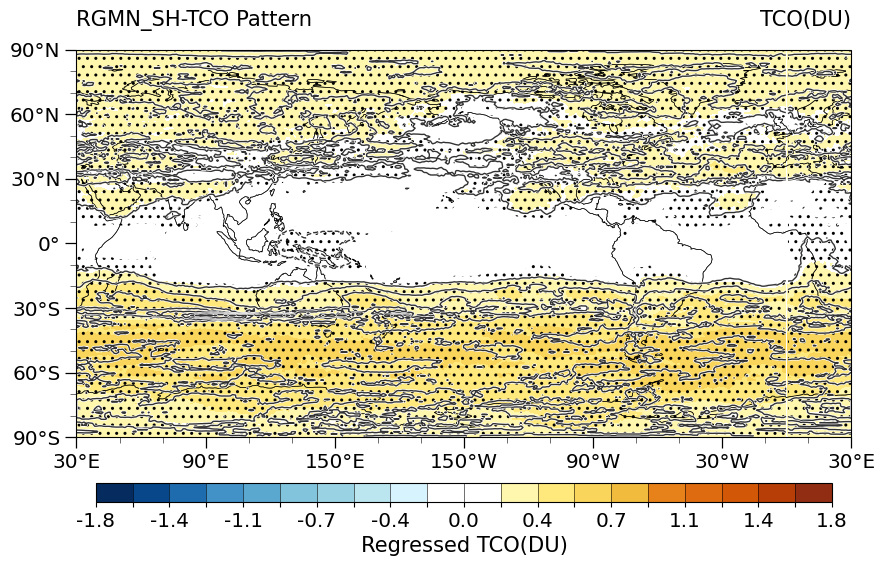

working on  ERA5 TCO
number of total months in data:  432


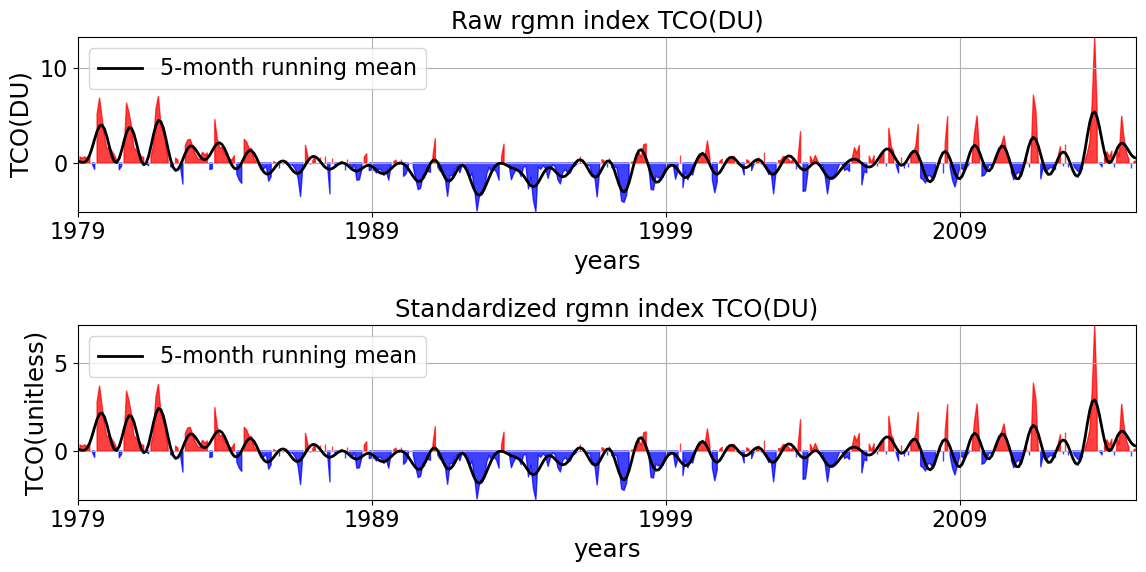

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


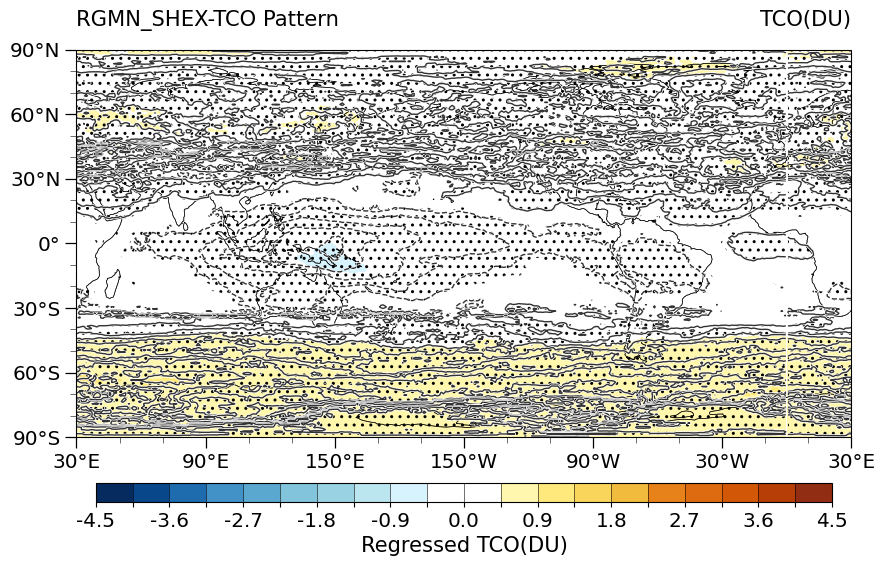

/lcrc/group/e3sm/ac.szhang/acme_scratch/data/pcmdi/model/monthly/analysis/ERA5/Amon/sco/analysis.historical.ERA5.en00.mon.sco.197901-201812.nc
working on  ERA5 SCO
number of total months in data:  432


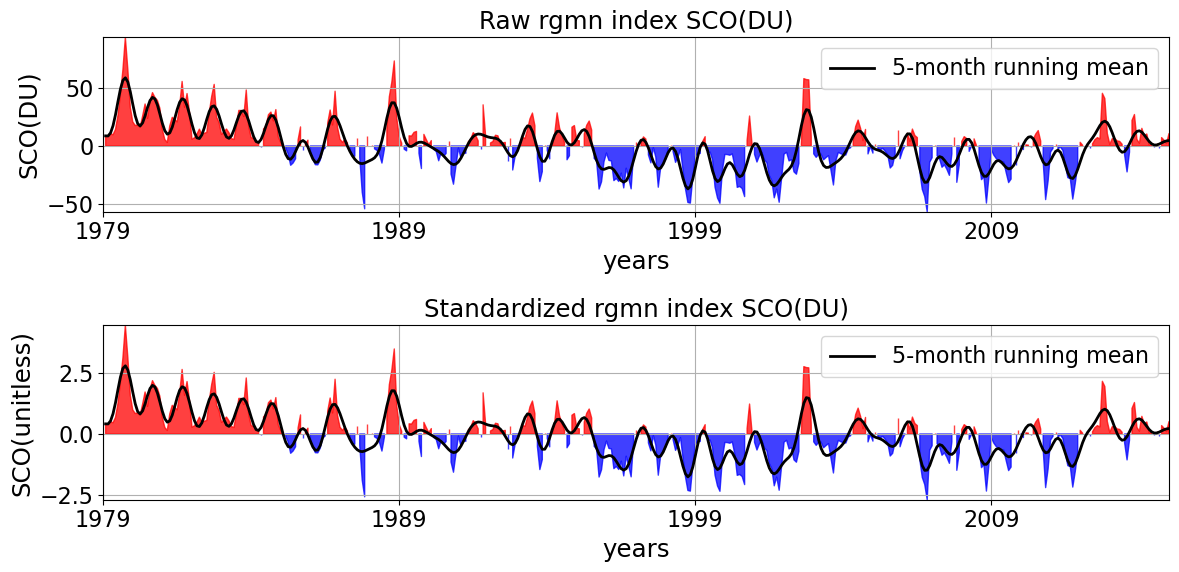

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


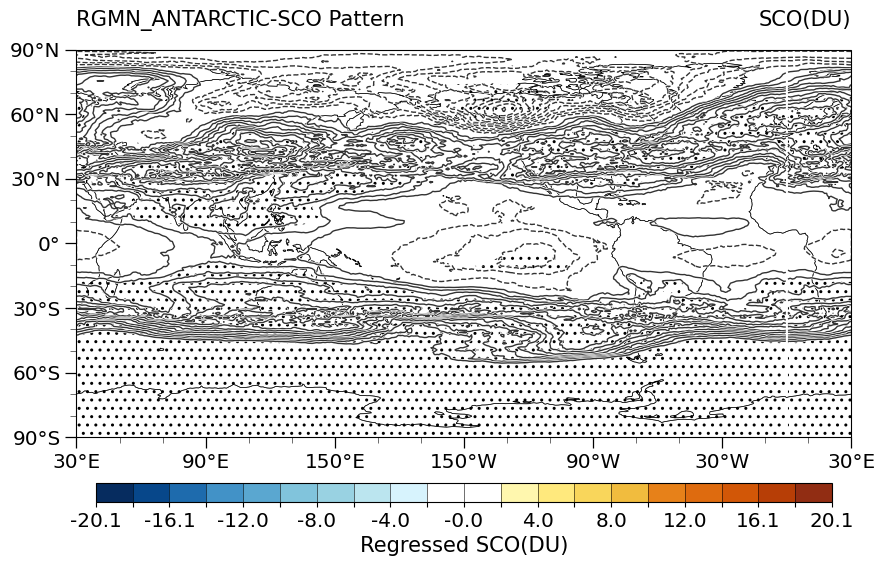

working on  ERA5 SCO
number of total months in data:  432


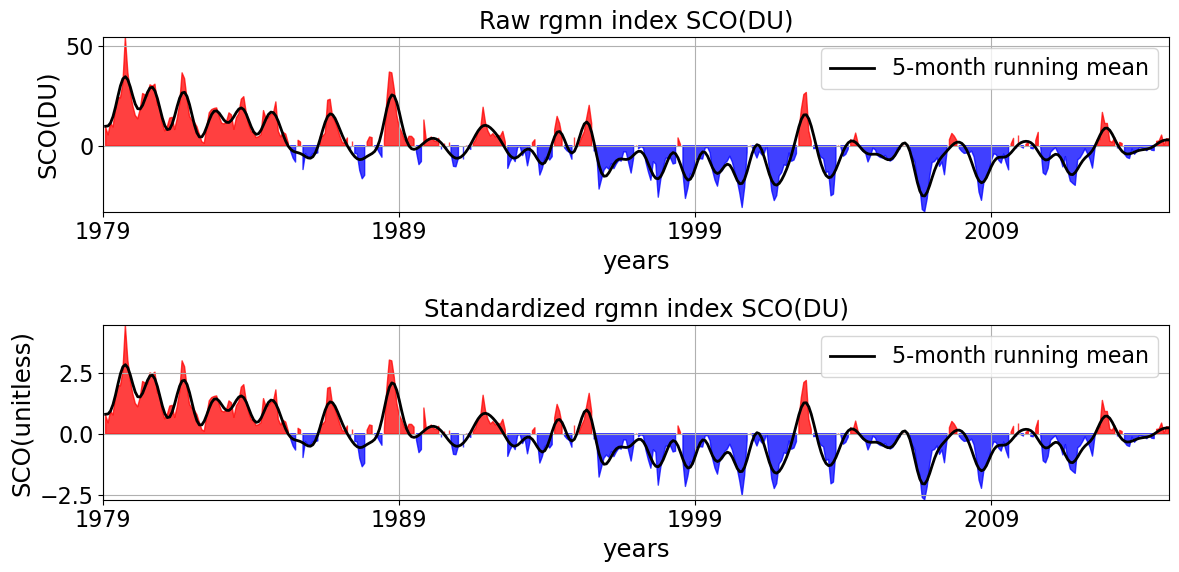

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


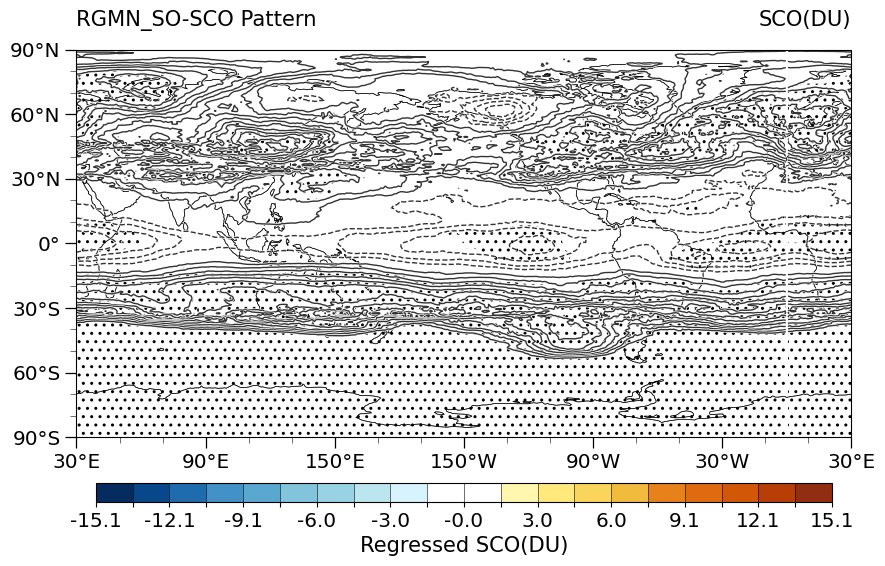

working on  ERA5 SCO
number of total months in data:  432


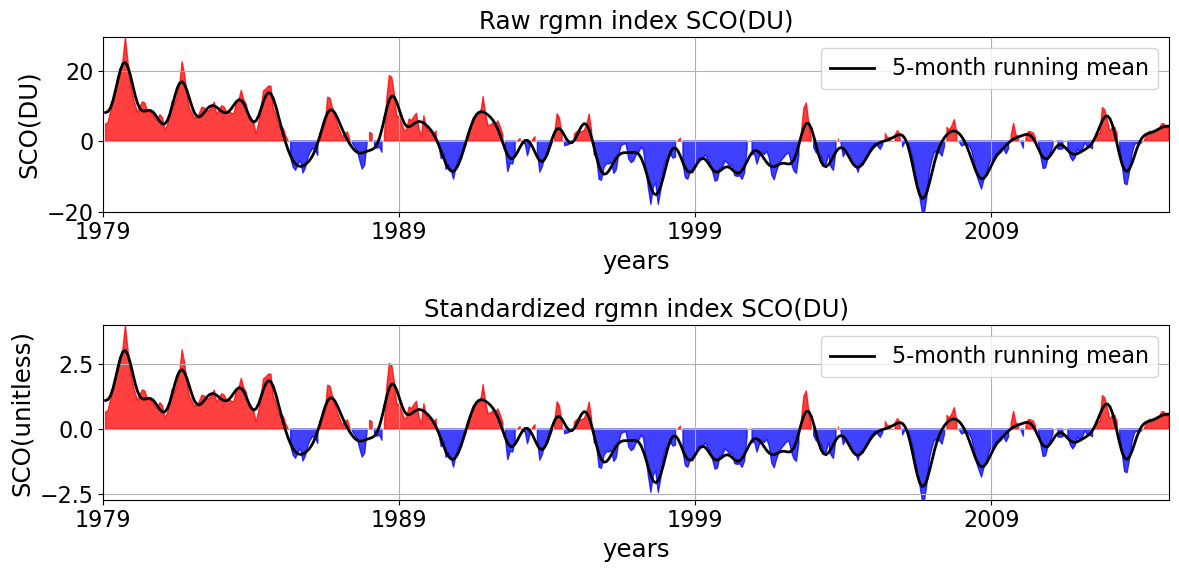

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


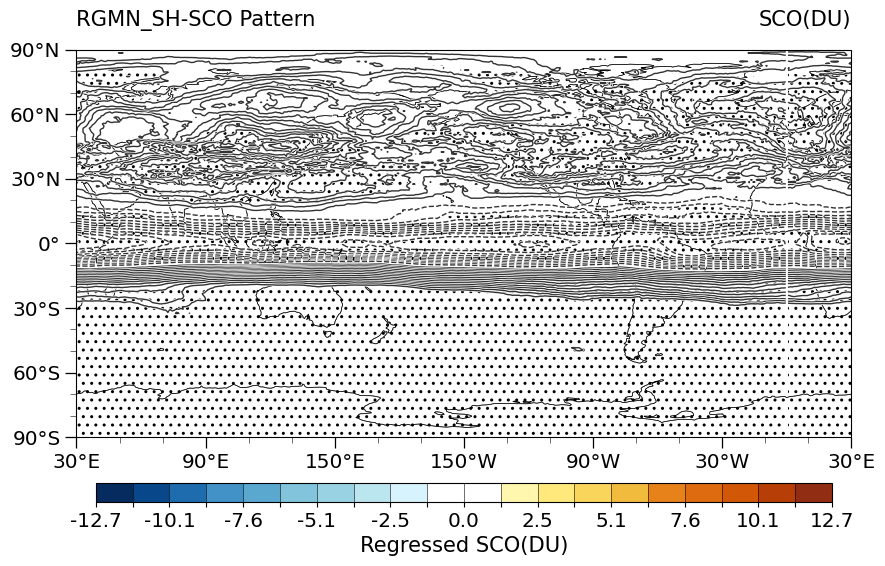

working on  ERA5 SCO
number of total months in data:  432


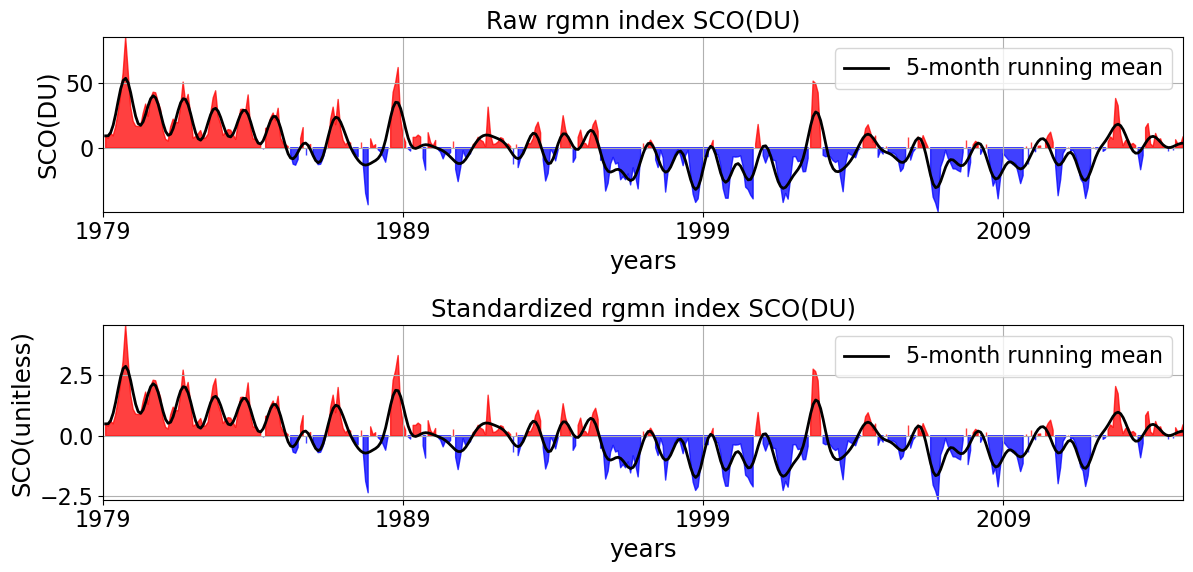

/tmp/ipykernel_2013631/778797275.py:72: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(rad.collections, path_effects=pe)


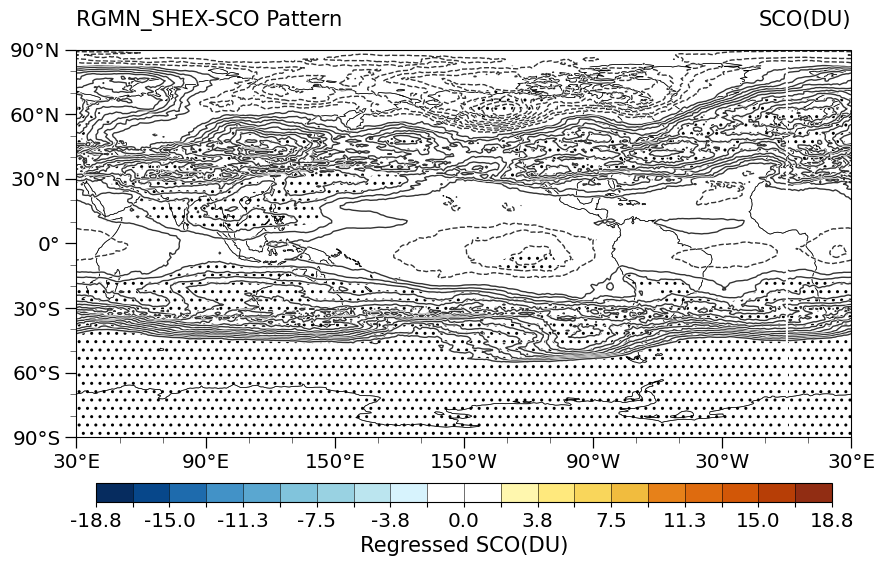